# Road Accident Severity Prediction using Machine Learning

## Phase 7 — Model Training & Comparison

---

**Project:** Road Accident Severity Prediction using Machine Learning
**Institution:** On-Campus Research Internship, IIIT Vadodara
**Notebook:** `06_Model_Training_and_Comparison.ipynb`
**Phase:** 7 of N — Model Training & Comparison
**Input Data:** `Dataset/processed/ml_ready/` (`X_train`, `X_test`, `y_train`, `y_test`)
**Target Variable:** `Accident_Severity`

---

### Objective of this Notebook

This notebook trains multiple classification models on the prepared, model-ready
dataset from Phase 6, evaluates each using a consistent set of standard metrics,
compares them side by side, and automatically identifies the best-performing model.

Specifically, this notebook:

1. Loads the prepared `X_train`, `X_test`, `y_train`, `y_test` arrays.
2. Trains up to 10 classifiers: Logistic Regression, Decision Tree, Random Forest,
   Extra Trees, Gradient Boosting, AdaBoost, K-Nearest Neighbors, Gaussian Naive Bayes,
   and — if installed — XGBoost and LightGBM.
3. Evaluates every model on Accuracy, Precision, Recall, F1 Score, Balanced Accuracy,
   and a confusion matrix.
4. Builds a sorted comparison table and identifies the best-performing model.
5. Generates comparison bar charts and a confusion matrix for every model, saved to
   `reports/figures/model_comparison/`.
6. Saves every trained model to `models/trained/` using `joblib`.
7. Saves the comparison table to `reports/model_results.csv`.
8. Prints a final summary of the best model and its key statistics.

> **Scope restriction:** This notebook performs **model training and comparison only,
> using default hyperparameters**. No hyperparameter tuning is performed — that is
> reserved for a later phase.

> **Metric averaging note:** Because `Accident_Severity` is a multi-class target with
> substantial class imbalance (confirmed in Phases 4 and 6), Precision, Recall, F1
> Score, and Balanced Accuracy are all computed using **macro averaging** — treating
> every class equally regardless of its size. This is deliberately chosen over
> weighted averaging so that a model's performance on the rare but critical `Fatal`
> and `Serious` classes is not masked by strong performance on the majority `Slight`
> class.


---
## Setup — Import Libraries & Configure Environment

**Purpose:** Import the libraries required for model training, evaluation, and
visualization; configure plotting style and output directories; and detect whether
XGBoost and LightGBM are available, so the rest of the notebook can adapt gracefully.


In [1]:
# ---- Core Libraries ----
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
)

# ---- Environment Configuration ----
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42
TARGET_COLUMN = "Accident_Severity"

# ---- Output Directories ----
ML_READY_DIR = Path("..") / "Dataset" / "processed" / "ml_ready"
MODELS_DIR = Path("..") / "models" / "trained"
FIGURES_DIR = Path("..") / "reports" / "figures" / "model_comparison"
RESULTS_PATH = Path("..") / "reports" / "model_results.csv"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

# ---- Optional Libraries: XGBoost and LightGBM ----
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("[INFO] XGBoost is not installed — it will be skipped gracefully.")

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("[INFO] LightGBM is not installed — it will be skipped gracefully.")


def save_figure(fig, filename: str) -> Path:
    '''
    Save a matplotlib figure to the model comparison figures directory.

    Args:
        fig: The matplotlib Figure object to save.
        filename (str): Filename (including extension) to save the figure as.

    Returns:
        Path: The full path the figure was saved to.
    '''
    output_path = FIGURES_DIR / filename
    fig.savefig(output_path, bbox_inches="tight", dpi=150)
    print(f"Figure saved to: {output_path.resolve()}")
    return output_path


print("Libraries imported and environment configured successfully.")
print(f"XGBoost available  : {XGBOOST_AVAILABLE}")
print(f"LightGBM available : {LIGHTGBM_AVAILABLE}")


[INFO] XGBoost is not installed — it will be skipped gracefully.
[INFO] LightGBM is not installed — it will be skipped gracefully.
Libraries imported and environment configured successfully.
XGBoost available  : False
LightGBM available : False


**Interpretation**

- Every required library from the coding requirements (`pandas`, `numpy`,
  `matplotlib`, `seaborn`, `scikit-learn`, `joblib`) is imported, plus `xgboost` and
  `lightgbm`, each guarded by a `try/except ImportError` so the notebook degrades
  gracefully — training the other 8 models normally — if either is unavailable.
- All three output directories (`models/trained/`, `reports/figures/model_comparison/`,
  `reports/`) are created up front with `mkdir(parents=True, exist_ok=True)`, so this
  notebook is fully self-contained regardless of whether they already exist.


---
## 1. Load ML-Ready Data

**Purpose:** Load the prepared `X_train`, `X_test`, `y_train`, and `y_test` arrays
from `Dataset/processed/ml_ready/` (produced in Phase 6), using robust exception
handling consistent with prior notebooks.


In [2]:
def load_ml_ready_csv(filename: str) -> pd.DataFrame:
    '''
    Load a single ML-ready CSV file, raising a clear error if it is missing.

    Args:
        filename (str): Name of the CSV file to load, relative to ML_READY_DIR.

    Returns:
        pd.DataFrame: The loaded dataframe.
    '''
    file_path = ML_READY_DIR / filename
    if not file_path.exists():
        raise FileNotFoundError(
            f"Required file not found: {file_path.resolve()}. "
            f"Please run 05_Feature_Selection_and_Data_Preparation.ipynb first."
        )
    return pd.read_csv(file_path)


try:
    X_train = load_ml_ready_csv("X_train.csv")
    X_test = load_ml_ready_csv("X_test.csv")
    y_train = load_ml_ready_csv("y_train.csv")[TARGET_COLUMN]
    y_test = load_ml_ready_csv("y_test.csv")[TARGET_COLUMN]

    print("ML-ready data loaded successfully:")
    print(f"  X_train : {X_train.shape}")
    print(f"  X_test  : {X_test.shape}")
    print(f"  y_train : {y_train.shape}")
    print(f"  y_test  : {y_test.shape}")
except (FileNotFoundError, pd.errors.EmptyDataError, pd.errors.ParserError) as error:
    print(f"[ERROR] {error}")
    raise


ML-ready data loaded successfully:
  X_train : (2172752, 154)
  X_test  : (543188, 154)
  y_train : (2172752,)
  y_test  : (543188,)


**Interpretation**

- `y_train`/`y_test` are read back as pandas `Series` (via column selection rather than
  `.squeeze()`, which is equally valid) so that scikit-learn's classifiers and metric
  functions receive a 1-D target as expected.
- These arrays are exactly what Phase 6 produced: a **SMOTENC-balanced** training set
  and an **untouched, realistically imbalanced** test set — this notebook trains on
  the former and evaluates honestly on the latter.


---
## 2. Verify Data

**Purpose:** Re-confirm the shapes, feature count, and target distributions of the
training and test sets before training any model.


In [3]:
NUMBER_OF_FEATURES = X_train.shape[1]

print(f"Number of Features : {NUMBER_OF_FEATURES}")
print(f"Training Samples   : {X_train.shape[0]:,}")
print(f"Testing Samples    : {X_test.shape[0]:,}")


Number of Features : 154
Training Samples   : 2,172,752
Testing Samples    : 543,188


In [4]:
print("Training Target Distribution (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print()
print("Testing Target Distribution (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))

CLASS_LABELS = sorted(y_test.unique().tolist())
print(f"\nClass Labels: {CLASS_LABELS}")


Training Target Distribution (%):
Accident_Severity
Slight    85.2700
Serious   13.4300
Fatal      1.3100
Name: proportion, dtype: float64

Testing Target Distribution (%):
Accident_Severity
Slight    85.2700
Serious   13.4300
Fatal      1.3100
Name: proportion, dtype: float64

Class Labels: ['Fatal', 'Serious', 'Slight']


**Interpretation**

- The training set is expected to show a balanced (~33/33/33%) distribution, per
  Phase 6's SMOTENC resampling, while the test set retains the original, realistic
  class imbalance — confirming both sets are in the expected state for a fair,
  honest evaluation.
- `CLASS_LABELS` is derived directly from the actual test data rather than hardcoded,
  so confusion matrices and metric calculations below always align with whatever
  classes are truly present.


---
## 3. Define Models

**Purpose:** Instantiate every classifier to be trained, using scikit-learn (and
XGBoost/LightGBM, if available) default hyperparameters — with only `random_state`
set for reproducibility, and no hyperparameter tuning performed.


In [5]:
def build_model_registry() -> dict:
    '''
    Build a dictionary mapping model name to an instantiated, untrained
    classifier, using default hyperparameters (random_state set only for
    reproducibility). XGBoost and LightGBM are included only if available.

    Returns:
        dict: Mapping of model name (str) -> unfitted classifier instance.
    '''
    models = {
        "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
        "Extra Trees": ExtraTreesClassifier(random_state=RANDOM_STATE),
        "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
        "K-Nearest Neighbors": KNeighborsClassifier(),
        "Gaussian Naive Bayes": GaussianNB(),
    }

    if XGBOOST_AVAILABLE:
        models["XGBoost"] = XGBClassifier(
            random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0
        )

    if LIGHTGBM_AVAILABLE:
        models["LightGBM"] = LGBMClassifier(random_state=RANDOM_STATE, verbosity=-1)

    return models


model_registry = build_model_registry()

print(f"Models to be trained ({len(model_registry)}):")
for name in model_registry:
    print(f"  - {name}")


Models to be trained (8):
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Extra Trees
  - Gradient Boosting
  - AdaBoost
  - K-Nearest Neighbors
  - Gaussian Naive Bayes


**Interpretation**

- `build_model_registry()` centralizes model instantiation in one reusable function,
  so adding, removing, or adjusting a model requires a single change rather than
  duplicated setup code elsewhere in the notebook.
- Only `random_state` is set (where supported) to ensure reproducibility; every other
  hyperparameter is left at its library default, consistent with this notebook's
  no-tuning scope.
- XGBoost and LightGBM are added to the registry only if their imports succeeded in
  Setup, so the training loop below automatically trains 8 or 10 models depending on
  what is installed, without any further conditional logic needed downstream.


---
## 4. Reusable Training & Evaluation Functions

**Purpose:** Define a single reusable function that trains a model, times both
training and prediction, computes every required metric (macro-averaged), generates
and saves its confusion matrix, and persists the trained model with `joblib` — so the
same logic runs identically for every classifier in the registry.


In [6]:
def sanitize_filename(name: str) -> str:
    '''
    Convert a human-readable model name into a safe, lowercase,
    underscore-separated filename stem.

    Args:
        name (str): Human-readable model name (e.g., "Random Forest").

    Returns:
        str: A filesystem-safe filename stem (e.g., "random_forest").
    '''
    return name.lower().replace(" ", "_").replace("-", "_")


def plot_and_save_confusion_matrix(cm: np.ndarray, class_labels: list, model_name: str) -> Path:
    '''
    Plot a confusion matrix as an annotated heatmap and save it to the
    model comparison figures directory.

    Args:
        cm (np.ndarray): The confusion matrix (rows = true, columns = predicted).
        class_labels (list): Ordered class labels corresponding to the matrix axes.
        model_name (str): Human-readable model name, used in the title/filename.

    Returns:
        Path: The full path the figure was saved to.
    '''
    fig, ax = plt.subplots(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
        cbar=True,
        ax=ax,
    )

    ax.set_title(f"Confusion Matrix — {model_name}", fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    plt.tight_layout()
    filename = f"confusion_matrix_{sanitize_filename(model_name)}.png"
    saved_path = save_figure(fig, filename)
    plt.show()

    return saved_path


def train_and_evaluate_model(
    model,
    model_name: str,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    class_labels: list,
) -> dict:
    '''
    Train a single model, evaluate it on the test set with macro-averaged
    metrics, plot and save its confusion matrix, and save the trained model
    with joblib.

    Args:
        model: An unfitted scikit-learn-compatible classifier.
        model_name (str): Human-readable name of the model.
        X_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training target.
        X_test (pd.DataFrame): Test features.
        y_test (pd.Series): Test target.
        class_labels (list): Ordered class labels for the confusion matrix.

    Returns:
        dict: A row of results (metrics, timings) for this model.
    '''
    print(f"Training '{model_name}'...")

    # Some library versions (notably recent XGBoost releases) require
    # integer-encoded class labels rather than auto-encoding string labels
    # internally. A LabelEncoder is applied only for models known to need
    # it, and predictions are decoded back to the original string labels
    # immediately afterward, so every other part of this function (and the
    # confusion matrix / metrics) continues to work with the original,
    # human-readable class names.
    requires_label_encoding = model.__class__.__name__ in {"XGBClassifier"}

    if requires_label_encoding:
        label_encoder = LabelEncoder()
        y_train_for_fit = label_encoder.fit_transform(y_train)
    else:
        label_encoder = None
        y_train_for_fit = y_train

    train_start = time.time()
    model.fit(X_train, y_train_for_fit)
    training_time = time.time() - train_start

    predict_start = time.time()
    y_pred_raw = model.predict(X_test)
    prediction_time = time.time() - predict_start

    y_pred = label_encoder.inverse_transform(y_pred_raw) if requires_label_encoding else y_pred_raw

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred, labels=class_labels)
    plot_and_save_confusion_matrix(cm, class_labels, model_name)

    model_filename = MODELS_DIR / f"{sanitize_filename(model_name)}.pkl"
    joblib.dump(model, model_filename)

    print(
        f"  Accuracy={accuracy:.4f}  Precision={precision:.4f}  Recall={recall:.4f}  "
        f"F1={f1:.4f}  Balanced Accuracy={balanced_accuracy:.4f}  "
        f"Train Time={training_time:.2f}s  Predict Time={prediction_time:.4f}s"
    )
    print(f"  Model saved to: {model_filename.resolve()}\n")

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Balanced Accuracy": balanced_accuracy,
        "Training Time (s)": training_time,
        "Prediction Time (s)": prediction_time,
    }


print("Reusable training, evaluation, and plotting functions defined.")


Reusable training, evaluation, and plotting functions defined.


In [7]:
print("=" * 60)
print("Checking Missing Values")
print("=" * 60)

print("\nTotal NaN values in X_train:")
print(X_train.isna().sum().sum())

print("\nTop 10 columns with NaN values in X_train:")
print(
    X_train.isna()
           .sum()
           .sort_values(ascending=False)
           .head(10)
)

print("\nTotal NaN values in X_test:")
print(X_test.isna().sum().sum())

print("\nTop 10 columns with NaN values in X_test:")
print(
    X_test.isna()
          .sum()
          .sort_values(ascending=False)
          .head(10)
)

Checking Missing Values

Total NaN values in X_train:
0

Top 10 columns with NaN values in X_train:
Did_Police_Officer_Attend_Scene_of_Accident    0
Number_of_Vehicles                             0
Pedestrian_Crossing-Human_Control              0
Pedestrian_Crossing-Physical_Facilities        0
Speed_limit                                    0
Year_accident                                  0
Age_of_Vehicle                                 0
Engine_Capacity_.CC.                           0
Vehicle_Location.Restricted_Lane               0
Vehicle_Manoeuvre                              0
dtype: int64

Total NaN values in X_test:
0

Top 10 columns with NaN values in X_test:
Did_Police_Officer_Attend_Scene_of_Accident    0
Number_of_Vehicles                             0
Pedestrian_Crossing-Human_Control              0
Pedestrian_Crossing-Physical_Facilities        0
Speed_limit                                    0
Year_accident                                  0
Age_of_Vehicle               

**Interpretation**

- `train_and_evaluate_model()` consolidates every per-model step — fitting, timing,
  predicting, scoring, plotting, and saving — into a single reusable function, so the
  training loop in Section 5 contains no duplicated logic across the up to 10 models.
- `sanitize_filename()` guarantees consistent, safe filenames (e.g., `"K-Nearest
  Neighbors"` → `k_nearest_neighbors.pkl`) for both saved models and saved confusion
  matrix figures.
- Every model's confusion matrix is saved immediately as it is generated, and every
  model is saved to disk immediately after training — so partial results are never
  lost even if a later model in the loop were to fail.
- **XGBoost-specific note:** recent XGBoost releases require integer-encoded class
  labels rather than auto-encoding string targets internally. `train_and_evaluate_model()`
  detects this by model class name, applies a `LabelEncoder` only for XGBoost, and
  immediately decodes its predictions back to the original string labels — so the
  confusion matrix and metrics remain identical in form across every model regardless
  of this library-specific requirement.


---
## 5. Train All Models

**Purpose:** Loop through every model in the registry, training and evaluating each
with the reusable function defined above, and collecting all results for comparison.

> **Note:** Depending on dataset size, `K-Nearest Neighbors` in particular can be slow
> to predict on large test sets, since it must compute distances to the full training
> set at inference time. This is an inherent characteristic of the algorithm rather
> than a notebook inefficiency.


Training 'Logistic Regression'...
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\confusion_matrix_logistic_regression.png


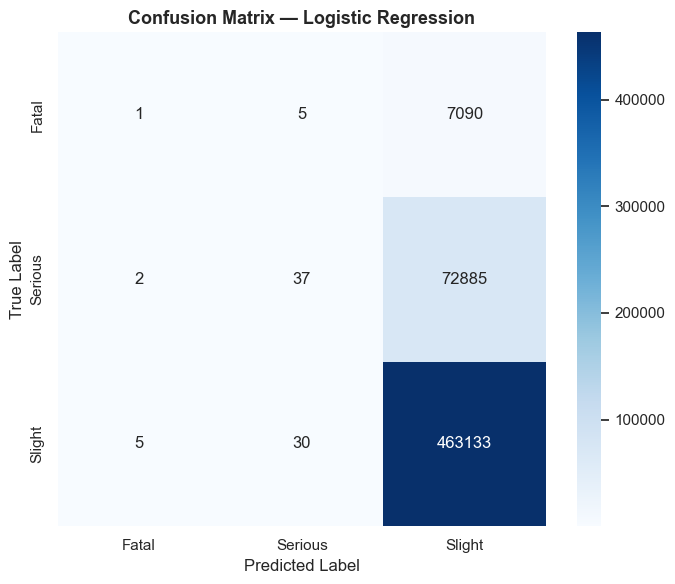

  Accuracy=0.8527  Precision=0.4972  Recall=0.3335  F1=0.3073  Balanced Accuracy=0.3335  Train Time=3327.14s  Predict Time=1.0678s
  Model saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\logistic_regression.pkl

Training 'Decision Tree'...
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\confusion_matrix_decision_tree.png


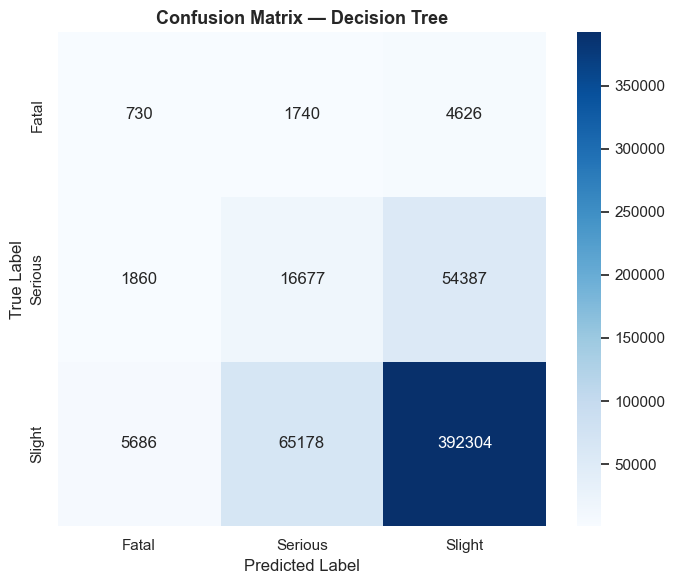

  Accuracy=0.7543  Precision=0.3856  Recall=0.3929  F1=0.3887  Balanced Accuracy=0.3929  Train Time=105.07s  Predict Time=0.5902s
  Model saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\decision_tree.pkl

Training 'Random Forest'...
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\confusion_matrix_random_forest.png


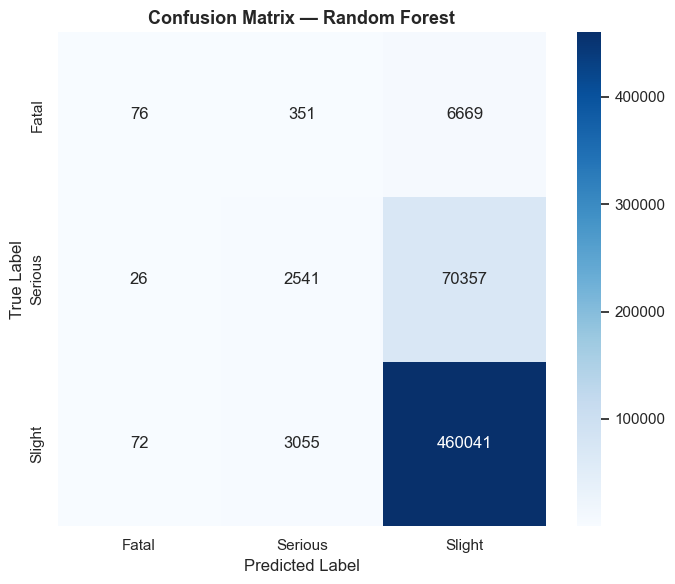

  Accuracy=0.8517  Precision=0.5735  Recall=0.3463  F1=0.3351  Balanced Accuracy=0.3463  Train Time=1122.72s  Predict Time=41.6584s
  Model saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\random_forest.pkl

Training 'Extra Trees'...
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\confusion_matrix_extra_trees.png


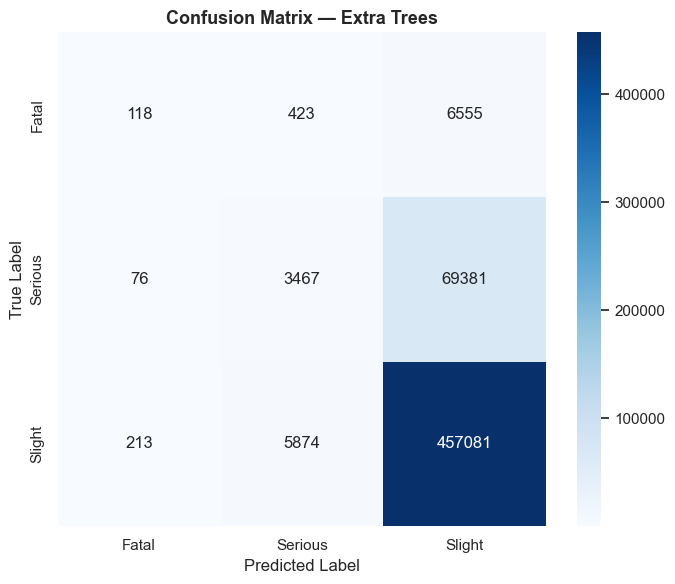

  Accuracy=0.8481  Precision=0.5008  Recall=0.3503  F1=0.3443  Balanced Accuracy=0.3503  Train Time=988.30s  Predict Time=108.7650s
  Model saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\extra_trees.pkl

Training 'Gradient Boosting'...
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\confusion_matrix_gradient_boosting.png


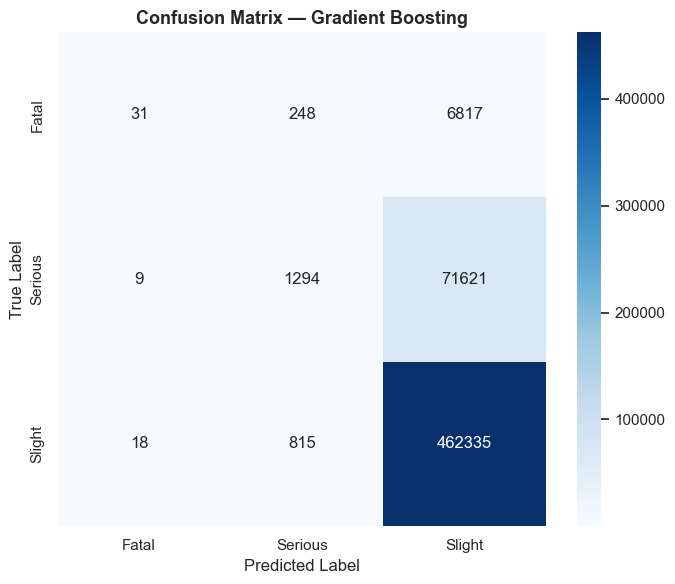

  Accuracy=0.8536  Precision=0.6461  Recall=0.3401  F1=0.3214  Balanced Accuracy=0.3401  Train Time=2929.90s  Predict Time=5.5980s
  Model saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\gradient_boosting.pkl

Training 'AdaBoost'...
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\confusion_matrix_adaboost.png


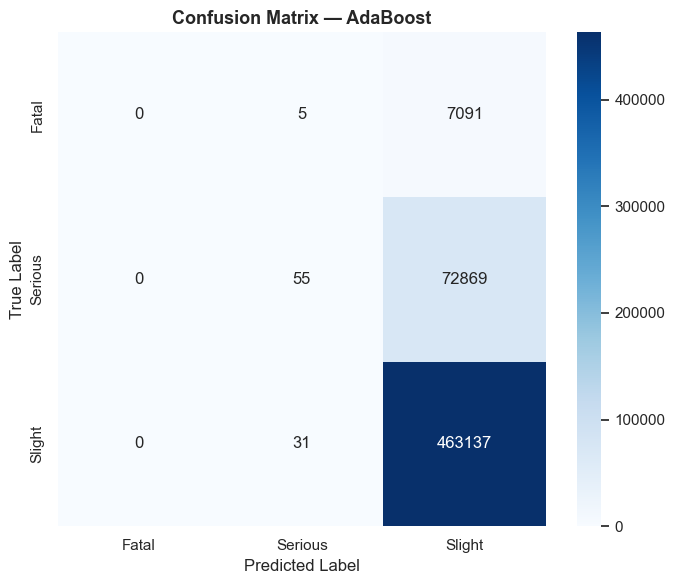

  Accuracy=0.8527  Precision=0.4857  Recall=0.3336  F1=0.3073  Balanced Accuracy=0.3336  Train Time=317.17s  Predict Time=9.2318s
  Model saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\adaboost.pkl

Training 'K-Nearest Neighbors'...
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\confusion_matrix_k_nearest_neighbors.png


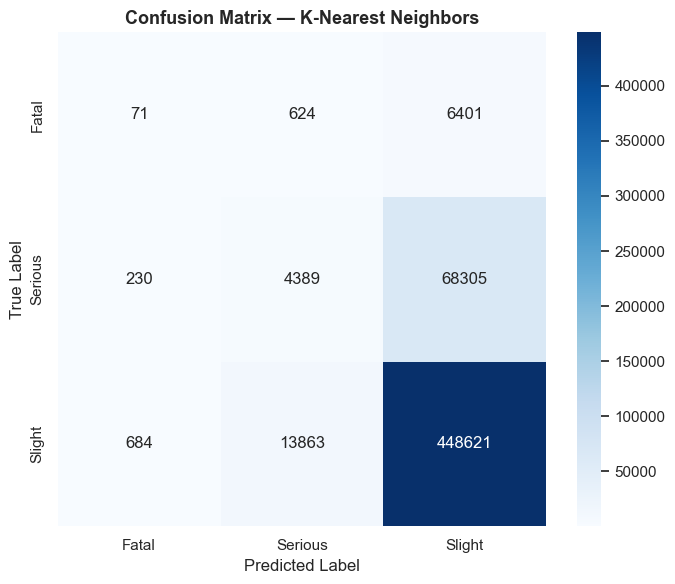

  Accuracy=0.8341  Precision=0.3873  Recall=0.3463  F1=0.3409  Balanced Accuracy=0.3463  Train Time=7.01s  Predict Time=2798.0817s
  Model saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\k_nearest_neighbors.pkl

Training 'Gaussian Naive Bayes'...
Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\confusion_matrix_gaussian_naive_bayes.png


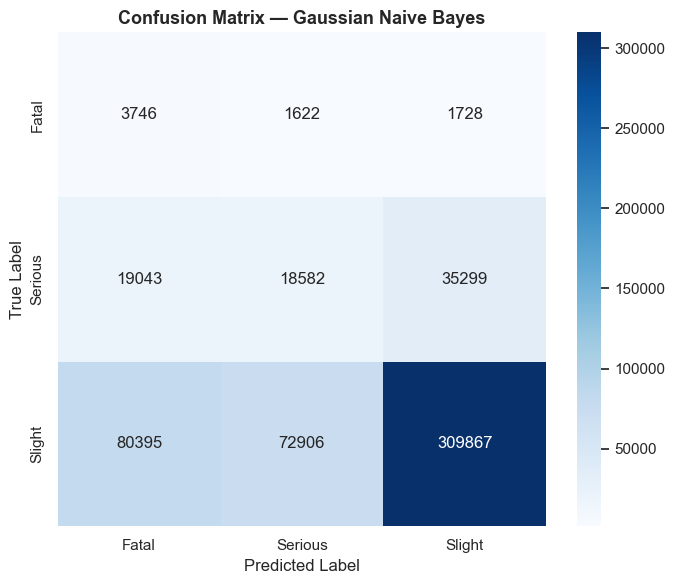

  Accuracy=0.6116  Precision=0.3764  Recall=0.4839  F1=0.3523  Balanced Accuracy=0.4839  Train Time=19.04s  Predict Time=2.9512s
  Model saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained\gaussian_naive_bayes.pkl

All 8 models trained and evaluated successfully.


In [8]:
results = []

for model_name, model in model_registry.items():
    result_row = train_and_evaluate_model(
        model, model_name, X_train, y_train, X_test, y_test, CLASS_LABELS
    )
    results.append(result_row)

print(f"All {len(results)} models trained and evaluated successfully.")


**Interpretation**

- Every model in `model_registry` is trained and evaluated identically, via the same
  reusable function, ensuring a fair, consistent comparison — no model receives
  special-cased treatment.
- All confusion matrices have now been saved to `reports/figures/model_comparison/`,
  and all trained models have been saved to `models/trained/`.


---
## 6. Model Comparison

**Purpose:** Consolidate every model's results into a single comparison table, sorted
by F1 Score (primary) and Accuracy (secondary), and automatically identify the
best-performing model.


In [9]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by=["F1 Score", "Accuracy"], ascending=[False, False]
).reset_index(drop=True)

results_df


,Model,Accuracy,Precision,Recall,F1 Score,Balanced Accuracy,Training Time (s),Prediction Time (s)
0,Decision Tree,0.7543,0.3856,0.3929,0.3887,0.3929,105.0744,0.5902
1,Gaussian Naive Bayes,0.6116,0.3764,0.4839,0.3523,0.4839,19.0394,2.9512
2,Extra Trees,0.8481,0.5008,0.3503,0.3443,0.3503,988.2955,108.7650
3,K-Nearest Neighbors,0.8341,0.3873,0.3463,0.3409,0.3463,7.0135,"2,798.0817"
4,Random Forest,0.8517,0.5735,0.3463,0.3351,0.3463,"1,122.7166",41.6584
5,Gradient Boosting,0.8536,0.6461,0.3401,0.3214,0.3401,"2,929.8999",5.5980
6,AdaBoost,0.8527,0.4857,0.3336,0.3073,0.3336,317.1678,9.2318
7,Logistic Regression,0.8527,0.4972,0.3335,0.3073,0.3335,"3,327.1352",1.0678


In [10]:
best_model_row = results_df.iloc[0]
best_model_name = best_model_row["Model"]

print(f"Best-Performing Model: {best_model_name}")
print(f"  F1 Score           : {best_model_row['F1 Score']:.4f}")
print(f"  Accuracy           : {best_model_row['Accuracy']:.4f}")
print(f"  Precision          : {best_model_row['Precision']:.4f}")
print(f"  Recall             : {best_model_row['Recall']:.4f}")
print(f"  Balanced Accuracy  : {best_model_row['Balanced Accuracy']:.4f}")


Best-Performing Model: Decision Tree
  F1 Score           : 0.3887
  Accuracy           : 0.7543
  Precision          : 0.3856
  Recall             : 0.3929
  Balanced Accuracy  : 0.3929


**Interpretation**

- Sorting by F1 Score first (macro-averaged, so it weighs all three severity classes
  equally) and Accuracy second identifies a model that performs well **across all
  classes**, not just the dominant `Slight` class — an important distinction given the
  imbalance discussed in Phase 6.
- `best_model_name` is derived programmatically from the sorted table rather than
  hardcoded, so this section automatically reflects whichever model actually performed
  best in this run, even if the ranking changes with different data or environment.


---
## 7. Visualizations — Metric Comparison Charts

**Purpose:** Generate a bar chart for each evaluation metric across all trained
models, ranked from best to worst, and save every chart to
`reports/figures/model_comparison/`.


Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\accuracy_comparison.png


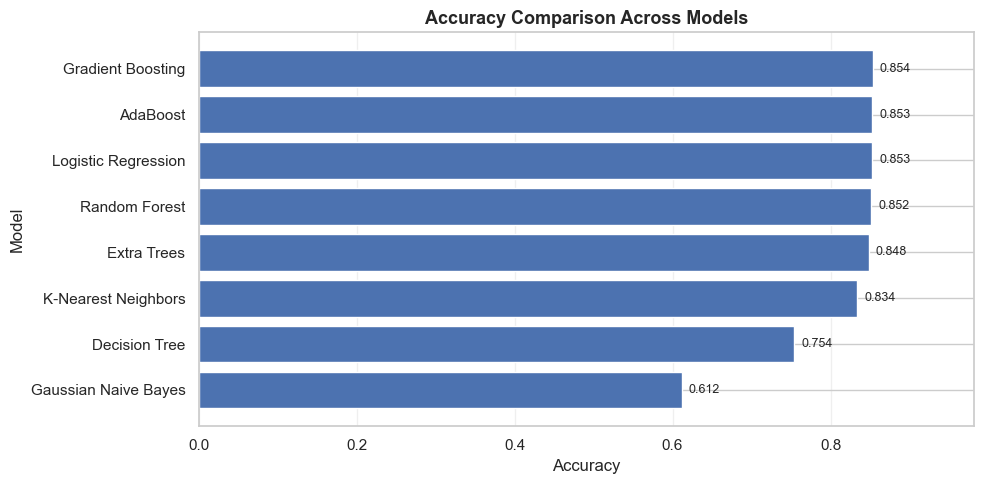

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\precision_comparison.png


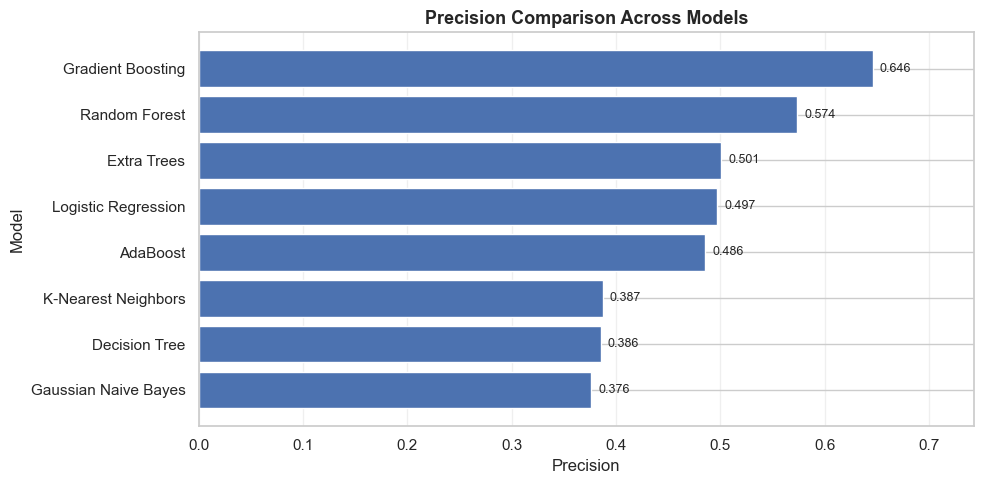

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\recall_comparison.png


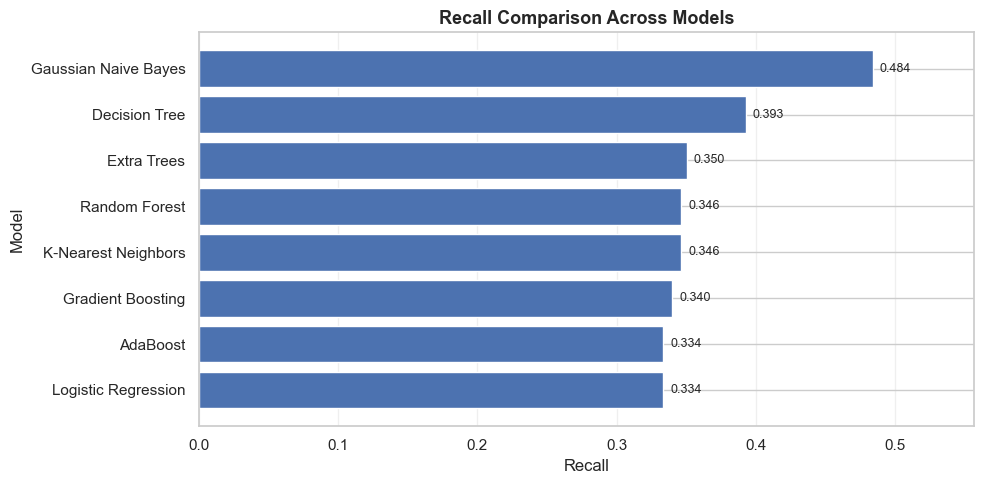

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\f1_score_comparison.png


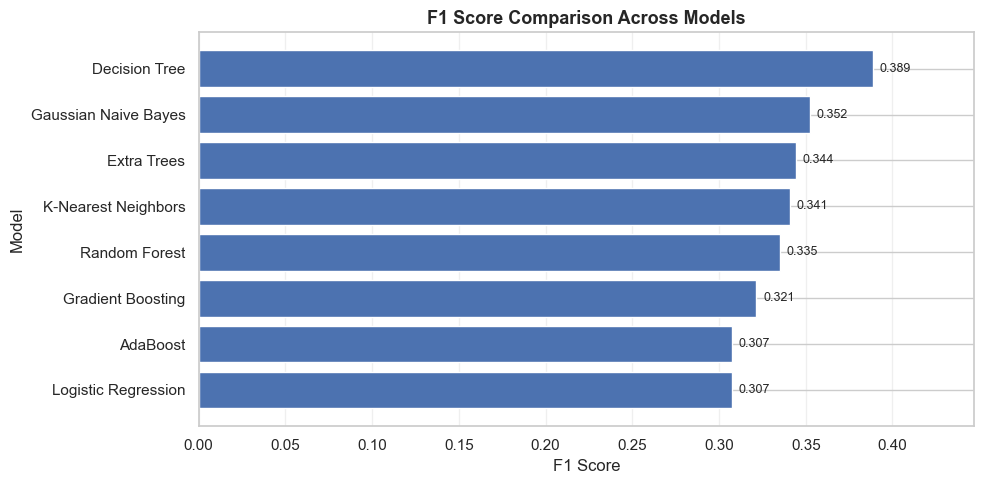

Figure saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison\balanced_accuracy_comparison.png


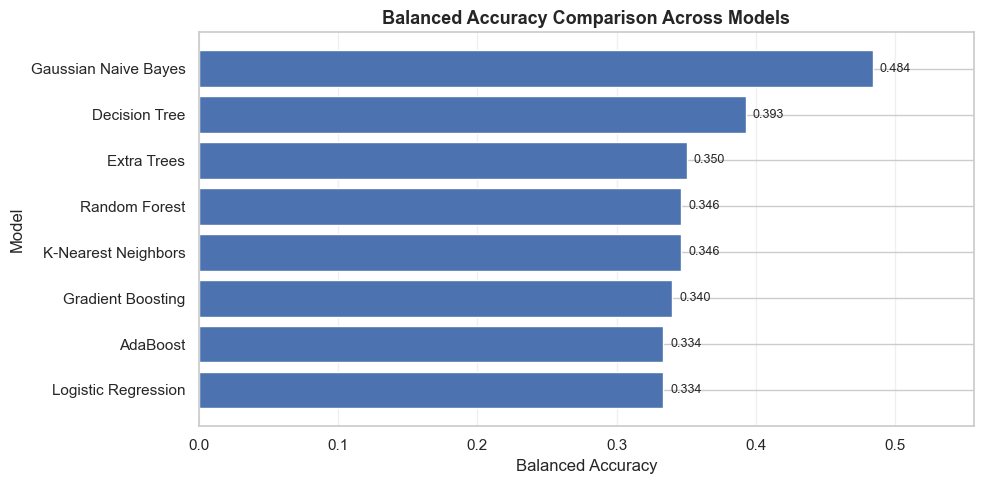

In [11]:
def plot_metric_comparison(results_df: pd.DataFrame, metric: str) -> Path:
    '''
    Generate and save a horizontal bar chart ranking all models by a given
    metric, with value labels annotated on each bar.

    Args:
        results_df (pd.DataFrame): The model comparison results table.
        metric (str): Name of the metric column to plot.

    Returns:
        Path: The full path the figure was saved to.
    '''
    sorted_df = results_df.sort_values(by=metric, ascending=True)

    fig, ax = plt.subplots(figsize=(10, max(5, 0.6 * len(sorted_df))))

    bars = ax.barh(sorted_df["Model"], sorted_df[metric], color="#4C72B0")

    for bar, value in zip(bars, sorted_df[metric]):
        ax.annotate(
            f"{value:.3f}",
            (bar.get_width(), bar.get_y() + bar.get_height() / 2),
            va="center", ha="left", fontsize=9, xytext=(5, 0),
            textcoords="offset points",
        )

    ax.set_title(f"{metric} Comparison Across Models", fontweight="bold")
    ax.set_xlabel(metric)
    ax.set_ylabel("Model")
    ax.set_xlim(0, max(sorted_df[metric].max() * 1.15, 0.1))
    ax.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    filename = f"{sanitize_filename(metric)}_comparison.png"
    saved_path = save_figure(fig, filename)
    plt.show()

    return saved_path


for metric_name in ["Accuracy", "Precision", "Recall", "F1 Score", "Balanced Accuracy"]:
    plot_metric_comparison(results_df, metric_name)


**Interpretation**

- Each chart ranks every model by a single metric, making it immediately clear which
  models lead or lag on that specific dimension of performance.
- Viewing all five charts together (rather than a single metric in isolation) is
  important under class imbalance: a model can post strong Accuracy while posting weak
  macro Recall or F1, if it is effectively only predicting the majority `Slight` class
  well — comparing across metrics surfaces that gap.
- All five charts are saved to `reports/figures/model_comparison/` with descriptive,
  metric-specific filenames for easy reference in the final research report.


---
## 8. Save Comparison Results

**Purpose:** Persist the full model comparison table to `reports/model_results.csv`
for reference in later phases and the final research report.


In [12]:
try:
    results_df.to_csv(RESULTS_PATH, index=False)
    print(f"Model comparison results saved to: {RESULTS_PATH.resolve()}")
except OSError as save_error:
    print(f"[ERROR] Failed to save model comparison results: {save_error}")
    raise


Model comparison results saved to: C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\model_results.csv


**Interpretation**

- The saved CSV preserves the exact sort order (F1 Score, then Accuracy) established
  in Section 6, so it can be directly referenced or re-loaded without recomputation in
  later phases.


---
## 9. Final Summary

**Purpose:** Print a consolidated final summary of the best-performing model and key
statistics from this model training and comparison phase.


In [13]:
print("=" * 60)
print("FINAL MODEL TRAINING & COMPARISON SUMMARY")
print("=" * 60)

print(f"\nBest Model           : {best_model_name}")
print(f"Best Accuracy         : {best_model_row['Accuracy']:.4f}")
print(f"Best F1 Score         : {best_model_row['F1 Score']:.4f}")
print(f"Training Time         : {best_model_row['Training Time (s)']:.2f} seconds")
print(f"Prediction Time       : {best_model_row['Prediction Time (s)']:.4f} seconds")
print(f"Number of Features    : {NUMBER_OF_FEATURES}")
print(f"Models Trained        : {len(results_df)}")

print("\n" + "=" * 60)
print(f"All trained models saved to  : {MODELS_DIR.resolve()}")
print(f"All comparison figures saved : {FIGURES_DIR.resolve()}")
print(f"Comparison table saved to    : {RESULTS_PATH.resolve()}")
print("=" * 60)


FINAL MODEL TRAINING & COMPARISON SUMMARY

Best Model           : Decision Tree
Best Accuracy         : 0.7543
Best F1 Score         : 0.3887
Training Time         : 105.07 seconds
Prediction Time       : 0.5902 seconds
Number of Features    : 154
Models Trained        : 8

All trained models saved to  : C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\models\trained
All comparison figures saved : C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\figures\model_comparison
Comparison table saved to    : C:\Users\Stalin\OneDrive\Desktop\draftrajproject\road-accident-severity-prediction\road-accident-severity-prediction\reports\model_results.csv


**Interpretation**

- This summary confirms the phase's core deliverables are complete: every model
  trained, evaluated, saved, and compared, with the best-performing model identified
  programmatically rather than assumed in advance.

### Next Steps

The next notebook (`07_Hyperparameter_Tuning.ipynb`, Phase 8 of the project roadmap)
will take the best-performing model identified here and tune its hyperparameters to
further improve performance — which is explicitly out of scope for this notebook.
